In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from kmodes.kmodes import KModes

In [17]:
bank = pd.read_csv('bankmarket.csv', sep=';')
bank.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [18]:
features = [col for col in bank.columns if col != 'y']
X = bank[features]
y = bank['y']

In [19]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

In [20]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_val = pd.get_dummies(X_val, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_val = X_val.reindex(columns=X_train.columns, fill_value=0)
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [21]:
mlp = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu', max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

val_pred_mlp = mlp.predict(X_val)
test_pred_mlp = mlp.predict(X_test)

val_acc_mlp = accuracy_score(y_val, val_pred_mlp)
test_acc_mlp = accuracy_score(y_test, test_pred_mlp)

print('MLP Validation Accuracy:', val_acc_mlp)
print('MLP Test Accuracy:', test_acc_mlp)

MLP Validation Accuracy: 0.9002913564260279
MLP Test Accuracy: 0.8927010843178508


In [22]:
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

val_pred_lr = lr.predict(X_val)
test_pred_lr = lr.predict(X_test)

val_acc_lr = accuracy_score(y_val, val_pred_lr)
test_acc_lr = accuracy_score(y_test, test_pred_lr)

print('Logistic Regression Validation Accuracy:', val_acc_lr)
print('Logistic Regression Test Accuracy:', test_acc_lr)

Logistic Regression Validation Accuracy: 0.914049854321787
Logistic Regression Test Accuracy: 0.9098559637481793


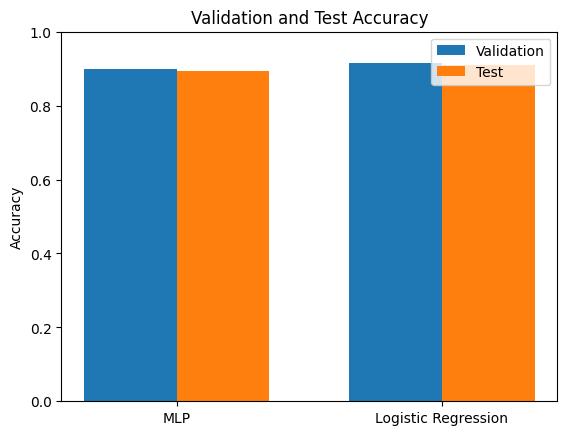

In [23]:
models = ['MLP', 'Logistic Regression']
val_acc = [val_acc_mlp, val_acc_lr]
test_acc = [test_acc_mlp, test_acc_lr]

x = np.arange(len(models))
w = 0.35

plt.bar(x - w/2, val_acc, w, label='Validation')
plt.bar(x + w/2, test_acc, w, label='Test')
plt.xticks(x, models)
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.title('Validation and Test Accuracy')
plt.legend()
plt.show()

In [24]:
columns = ['parents', 'has_nurs', 'form', 'children', 'housing', 'finance', 'social', 'health', 'Class']
nursery = pd.read_csv('nursery.data', header=None, names=columns)

nursery['children'] = nursery['children'].replace({'more': '3'}).astype('category')

X = nursery.drop('Class', axis=1)
y = nursery['Class']

In [25]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

In [26]:
k_values = list(range(2, 9))
cost = []

for k in k_values:
    km = KModes(n_clusters=k, init='Huang', n_init=5, random_state=42)
    km.fit(X_train)
    cost.append(km.cost_)

curvature = np.diff(cost, 2)
optimal_k = k_values[int(np.argmax(curvature)) + 1]

print('Optimal k:', optimal_k)

Optimal k: 3


In [27]:
km = KModes(n_clusters=optimal_k, init='Huang', n_init=10, random_state=42)
train_clusters = km.fit_predict(X_train)
test_clusters = km.predict(X_test)

centroids = pd.DataFrame(km.cluster_centroids_, columns=X_train.columns)
print('Cluster Centroids')
print(centroids)

train_counts = pd.Series(train_clusters).value_counts().sort_index()
test_counts = pd.Series(test_clusters).value_counts().sort_index()

print('Train Cluster Counts')
print(train_counts)
print('Test Cluster Counts')
print(test_counts)

train_cluster_series = pd.Series(train_clusters, index=X_train.index)
test_cluster_series = pd.Series(test_clusters, index=X_test.index)

cluster_labels = {}
for c in range(optimal_k):
    cluster_labels[c] = y_train[train_cluster_series == c].mode()[0]

print('Cluster Labels')
print(cluster_labels)

train_labeled = train_cluster_series.map(cluster_labels)
test_labeled = test_cluster_series.map(cluster_labels)

print('Train Labeled Cluster Counts')
print(train_labeled.value_counts())
print('Test Labeled Cluster Counts')
print(test_labeled.value_counts())

Cluster Centroids
       parents   has_nurs       form children     housing     finance  \
0   great_pret     proper   complete        3  convenient      inconv   
1        usual   critical     foster        3    critical  convenient   
2  pretentious  very_crit  completed        2  convenient  convenient   

          social       health  
0        nonprob  recommended  
1    problematic     priority  
2  slightly_prob    not_recom  
Train Cluster Counts
0    4094
1    3055
2    1923
Name: count, dtype: int64
Test Cluster Counts
0    1822
1    1259
2     807
Name: count, dtype: int64
Cluster Labels
{0: 'priority', 1: 'spec_prior', 2: 'not_recom'}
Train Labeled Cluster Counts
priority      4094
spec_prior    3055
not_recom     1923
Name: count, dtype: int64
Test Labeled Cluster Counts
priority      1822
spec_prior    1259
not_recom      807
Name: count, dtype: int64


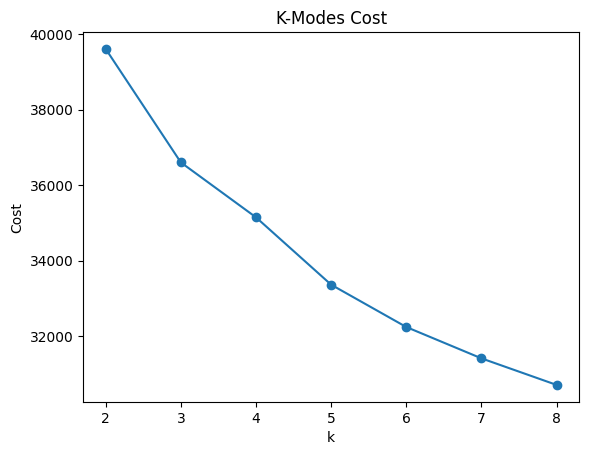

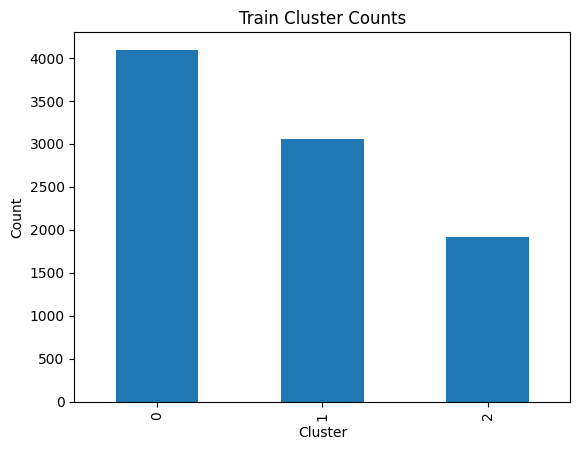

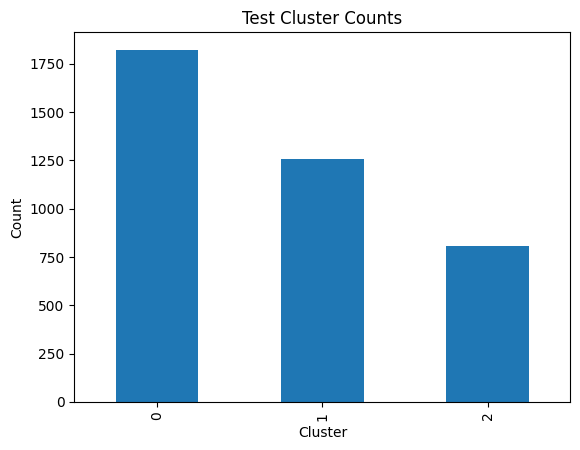

In [28]:
plt.plot(k_values, cost, marker='o')
plt.xlabel('k')
plt.ylabel('Cost')
plt.title('K-Modes Cost')
plt.show()

train_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Train Cluster Counts')
plt.show()

test_counts.plot(kind='bar')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Test Cluster Counts')
plt.show()